In [17]:
from PIL import Image
import torch
from torchvision import transforms, datasets
import math
from matplotlib import pyplot as plt

In [2]:
torch.manual_seed(42)

## ゼロパディング

In [3]:
def zeroPadding(image, padding=0):
    """
    Args:
        kernel_shape : (N, C, H, W)
    """
    N, C, H, W = image.shape
    
    # paddingが0以下なら処理を終了する
    if padding <= 0 :
        return image
    
    padding_image = torch.zeros(N, C, H + padding * 2, W + padding * 2, dtype=torch.float)
    
    padding_image[:, :, padding : -padding , padding : -padding] = image
    
    return padding_image

## 出力画像サイズの計算処理

In [4]:
def convN(x, kernel, padding, stride):
    """カーネルをずらし、加重和を計算する回数を計算(カーネルで覆えない部分は除外)
    出力画像サイズを返すことと同義
    """
    cn = (((x + padding * 2) - kernel) / stride) + 1
    return math.floor(cn) # カーネル外を除外

## 畳み込みの順伝搬

In [ ]:
### 2次元のフィルターを実装する(N=1, C=1, padding=可変, stride=可変)
def conv2d(kernel_shape : tuple, image : torch.tensor, padding:int=1, stride:int=1, bias=False):
    """
    Args:
        kernel_shape : (out_channels, input_channels, H, W)
        image.shape : (N, input_channels, H, W)
        padding :
        stride : 
    """
    
    N, C, H, W = image.shape
    
    out_channels, input_channels, fH, fW = kernel_shape
    
    # 入力画像とカーネルのinput_channel一致チェック
    assert input_channels == C
    
    # カーネルとバイアスの定義
    kernel = torch.randint(0, 10, (kernel_shape), dtype=torch.float)
    b = torch.zeros((out_channels, 1, 1))
    
    # フィルターが縦に動く回数
    row_n = convN(H, fH, padding, stride)
    # フィルターが横に動く回数
    col_n = convN(W, fW, padding, stride)
    
    # 畳み込み結果行列
    conv_image = torch.zeros((N, out_channels, row_n, col_n))
    
    # パディング
    image = zeroPadding(image, padding)
    print(f"padding image \n {image}")
    print(f"kernel : \n {kernel}")
    
    # outputチャネル数
    for o in range(out_channels):
        # 1時畳み込み行列(input_kernel分の行列を保持)
        tmp_image = torch.zeros((N, C, row_n, col_n))
        # バッチサイズ数
        for n in range(N):
            # インプットチャネル数
            for c in range(C):
                # 画像の高さ
                for r in range(row_n):
                    # 画像の幅
                    for w in range(col_n):
                        clip_image = image[n, c, r * stride : r * stride +  fH, w * stride : w * stride + fW]
                        # ここでは、数学的な畳み込みではなく相互相関を計算している。本当の畳み込みはカーネルを反転する
                        # CNNでは、カーネルの値が学習によって求められるため、反転する計算コストを削減している
                        ckernel = kernel[o, c]
                        scalar = clip_image.flatten() @ ckernel.flatten()
                        print(f"========channel: {c}, row : {r}, width : {w}===========")
                        print(f"切り取り画像 \n {clip_image}")
                        print(f"計算結果 \n {scalar}")
                        tmp_image[n, c, r, w] = scalar

        outc = tmp_image.sum(dim=1) # チャンネルごとに畳み込み結果を加算
        conv_image[:, o] = outc # 出力チャネル1個分の畳み込み結果を格納
        print(f"入力チャネル数ごとの畳み込み : {outc}")
        
    # バイアスを加算
    if bias:
        conv_image = conv_image + b

    return conv_image

In [6]:
n = 5
c = 3
s = 4
image = torch.arange(n*c*s*s, dtype=torch.float).reshape(n, c, s, s)
padding = 1
stride = 2
out_channels = 2

fH = 3 
fW = 3

kernel_shape = (out_channels, c, fH, fW)
print(f"画像表示")
print(image)
print(image.shape)
print(kernel_shape)

conv_image = conv2d(kernel_shape, image, padding, stride)
print(f"畳み込み結果 : \n {conv_image}")

画像表示
tensor([[[[  0.,   1.,   2.,   3.],
          [  4.,   5.,   6.,   7.],
          [  8.,   9.,  10.,  11.],
          [ 12.,  13.,  14.,  15.]],

         [[ 16.,  17.,  18.,  19.],
          [ 20.,  21.,  22.,  23.],
          [ 24.,  25.,  26.,  27.],
          [ 28.,  29.,  30.,  31.]],

         [[ 32.,  33.,  34.,  35.],
          [ 36.,  37.,  38.,  39.],
          [ 40.,  41.,  42.,  43.],
          [ 44.,  45.,  46.,  47.]]],


        [[[ 48.,  49.,  50.,  51.],
          [ 52.,  53.,  54.,  55.],
          [ 56.,  57.,  58.,  59.],
          [ 60.,  61.,  62.,  63.]],

         [[ 64.,  65.,  66.,  67.],
          [ 68.,  69.,  70.,  71.],
          [ 72.,  73.,  74.,  75.],
          [ 76.,  77.,  78.,  79.]],

         [[ 80.,  81.,  82.,  83.],
          [ 84.,  85.,  86.,  87.],
          [ 88.,  89.,  90.,  91.],
          [ 92.,  93.,  94.,  95.]]],


        [[[ 96.,  97.,  98.,  99.],
          [100., 101., 102., 103.],
          [104., 105., 106., 107.],
       

## 畳み込みの逆伝搬時に求める勾配の種類

- カーネルの勾配
- 入力画像の勾配
- バイアスの勾配

In [7]:
dataloader_train = torch.utils.data.DataLoader(
    datasets.CIFAR10("./data/cifar10", train=True, download=True, transform=transforms.ToTensor()),
    batch_size=1,
    shuffle=False
)

100%|██████████| 170M/170M [2:38:23<00:00, 17.9kB/s]   
c:\Users\siran\ML\CNN_Visualization\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


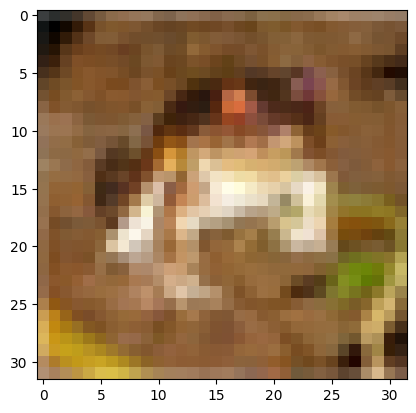

In [29]:
cifar_imsample,  cifar_labelsample = next(iter(dataloader_train))
plt.imshow(cifar_imsample.squeeze(dim=0).permute(1, 2, 0).detach().numpy())

In [36]:
kernel_shape = (3, 3, 3, 3)
padding = 1
stride = 1
bias = False
conv_image = conv2d(kernel_shape, cifar_imsample, padding, stride, bias)

padding image 
 tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.2314, 0.1686,  ..., 0.5961, 0.5804, 0.0000],
          [0.0000, 0.0627, 0.0000,  ..., 0.4667, 0.4784, 0.0000],
          ...,
          [0.0000, 0.7059, 0.6784,  ..., 0.3804, 0.3255, 0.0000],
          [0.0000, 0.6941, 0.6588,  ..., 0.5922, 0.4824, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.2431, 0.1804,  ..., 0.4902, 0.4863, 0.0000],
          [0.0000, 0.0784, 0.0000,  ..., 0.3255, 0.3412, 0.0000],
          ...,
          [0.0000, 0.5451, 0.4824,  ..., 0.2431, 0.2078, 0.0000],
          [0.0000, 0.5647, 0.5059,  ..., 0.4627, 0.3608, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.2471, 0.1765,  ..., 0.4000, 0.4039, 0.0000],
          [0.0000, 0.0784,

In [37]:
conv_image.shape

torch.Size([1, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.5882354..116.36471].


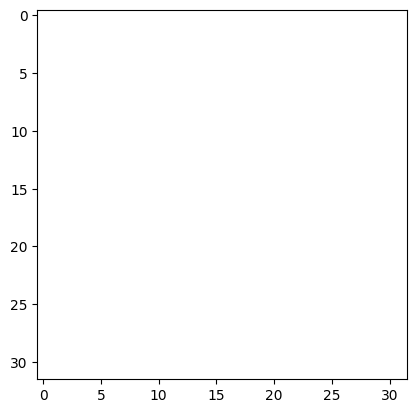

In [38]:
plt.imshow(conv_image.squeeze(dim=0).permute(1, 2, 0).detach().numpy())